# QM Ch 2 — Time-Independent Schrödinger Equation: Figure Notebook

**Griffiths & Schroeter, *Introduction to Quantum Mechanics* (3rd ed.)**  
SeoulTech PSE Lab

| Fig | File | Topic | Slide |
|-----|------|-------|-------|
| 1 | `ch02_fig1_infinite_well.png` | Infinite square well — $\psi_n$, $|\psi_n|^2$, energy levels | §2.2 |
| 2 | `ch02_fig2_harmonic_oscillator.png` | Harmonic oscillator — wavefunctions & energy ladder | §2.3 |
| 3 | `ch02_fig3_free_particle.png` | Free particle — wave packet dispersion & group velocity | §2.4 |
| 4 | `ch02_fig4_delta_potential.png` | Delta-function potential — bound state & R, T vs. E | §2.5 |
| 5 | `ch02_fig5_finite_well.png` | Finite square well — wavefunctions & transcendental eqn | §2.6 |

In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite
from scipy.optimize import brentq

# ── Dark theme matching qm_slides.css ──────────────────────────
BG    = '#1e1e2e'
BG2   = '#27273d'
FG    = '#cdd6f4'
MUTED = '#6c7086'
BLUE  = '#5b8dd9'
SKY   = '#89b4fa'
TEAL  = '#74c7ec'
MAUVE = '#cba6f7'
GREEN = '#a6e3a1'
AMBER = '#f9e2af'
RED   = '#f38ba8'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': BG2,
    'axes.edgecolor':   MUTED, 'axes.labelcolor': FG,
    'xtick.color':      MUTED, 'ytick.color':     MUTED,
    'text.color':       FG,   'grid.color':       '#313244',
    'grid.linewidth':   0.5,  'grid.alpha':       0.6,
    'font.family':      'sans-serif', 'font.size': 12,
    'axes.titlesize':   13,   'axes.titleweight': 'bold',
    'axes.labelsize':   11,   'legend.fontsize':  10,
    'legend.facecolor': BG2,  'legend.edgecolor': MUTED,
    'lines.linewidth':  2.0,  'figure.dpi':       130,
})
SAVEKW = dict(dpi=150, bbox_inches='tight', facecolor=BG)
print('Setup complete.')

Setup complete.


## Fig 1 — Infinite Square Well (§2.2)

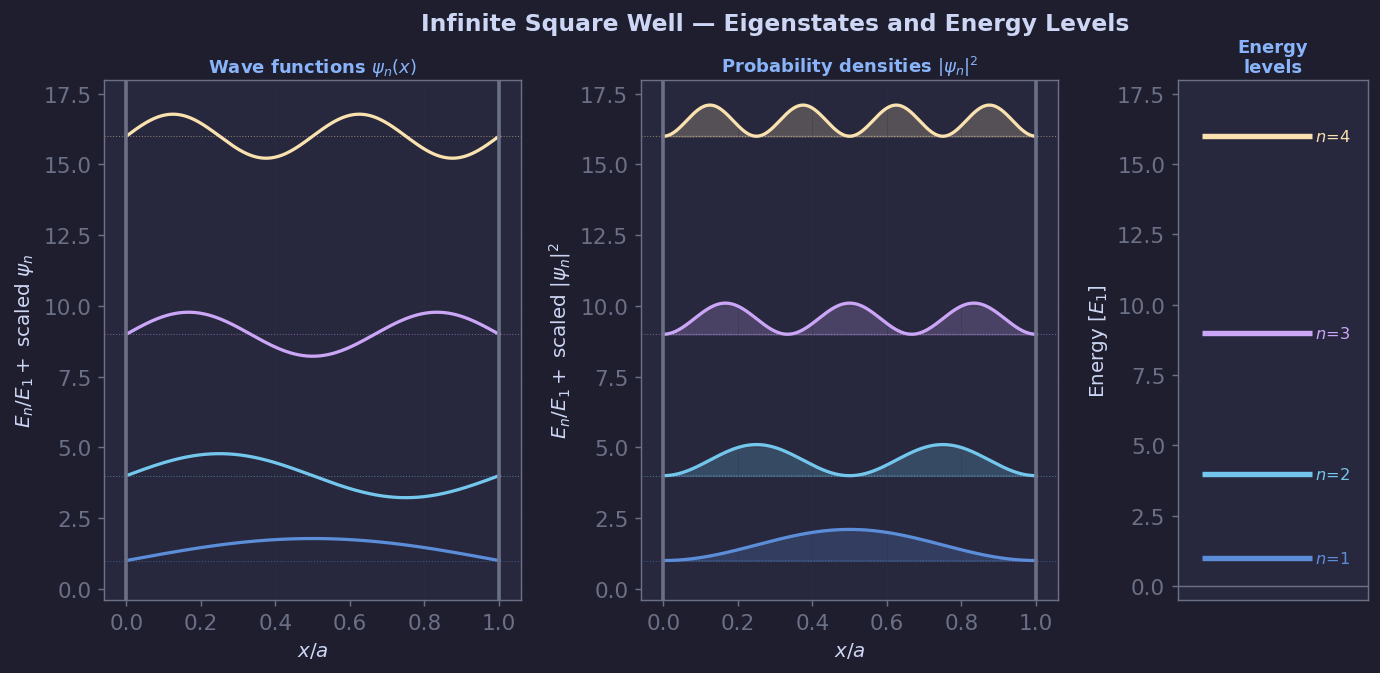

Fig 1 saved.


In [2]:
a  = 1.0;  E1 = 1.0
ns = [1, 2, 3, 4]
x  = np.linspace(0, a, 800)
colors = [BLUE, TEAL, MAUVE, AMBER]

fig = plt.figure(figsize=(12, 5.2))
fig.suptitle('Infinite Square Well — Eigenstates and Energy Levels',
             color=FG, fontsize=13, fontweight='bold', y=0.98)
gs = fig.add_gridspec(1, 3, width_ratios=[2.2, 2.2, 1.0],
                      left=0.07, right=0.88, wspace=0.35)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

scale = 0.55
for n, col in zip(ns, colors):
    En  = n**2 * E1
    psi = np.sqrt(2/a) * np.sin(n*np.pi*x/a)
    ax1.plot(x, scale*psi + En, color=col, lw=1.8)
    ax1.axhline(En, color=col, lw=0.6, ls=':', alpha=0.45)
    ax2.fill_between(x, En, scale*psi**2 + En, alpha=0.22, color=col)
    ax2.plot(x, scale*psi**2 + En, color=col, lw=1.8,
             label=fr'$n={n},\ E={n**2}E_1$')
    ax2.axhline(En, color=col, lw=0.6, ls=':', alpha=0.45)
    ax3.hlines(En, 0.15, 0.85, colors=col, lw=3)
    ax3.text(0.87, En, fr'$n\!=\!{n}$', color=col, va='center', fontsize=9)

for ax in [ax1, ax2]:
    ax.axvline(0, color=MUTED, lw=2); ax.axvline(a, color=MUTED, lw=2)
    ax.set_xlabel(r'$x/a$'); ax.set_xlim(-0.06, 1.06)
    ax.set_ylim(-0.4, 18); ax.grid(True, alpha=0.35)

ax1.set_ylabel(r'$E_n/E_1 +$ scaled $\psi_n$')
ax1.set_title(r'Wave functions $\psi_n(x)$', color=SKY, fontsize=10, pad=4)
ax2.set_ylabel(r'$E_n/E_1 +$ scaled $|\psi_n|^2$')
ax2.set_title(r'Probability densities $|\psi_n|^2$', color=SKY, fontsize=10, pad=4)

# # Legend right of ax2, inside figure margin
# leg = ax2.legend(fontsize=8.5, loc='upper left',
#                  bbox_to_anchor=(1.04, 1.0), borderaxespad=0,
#                  framealpha=0.85)

ax3.set_xlim(0, 1.2); ax3.set_ylim(-0.5, 18)
ax3.set_ylabel(r'Energy $[E_1]$'); ax3.set_xticks([])
ax3.set_title('Energy\nlevels', color=SKY, fontsize=10, pad=4)
ax3.grid(True, axis='y', alpha=0.35); ax3.axhline(0, color=MUTED, lw=0.8)

plt.savefig('ch02_fig1_infinite_well.png', **SAVEKW)
plt.show(); print('Fig 1 saved.')


## Fig 2 — Harmonic Oscillator (§2.3)

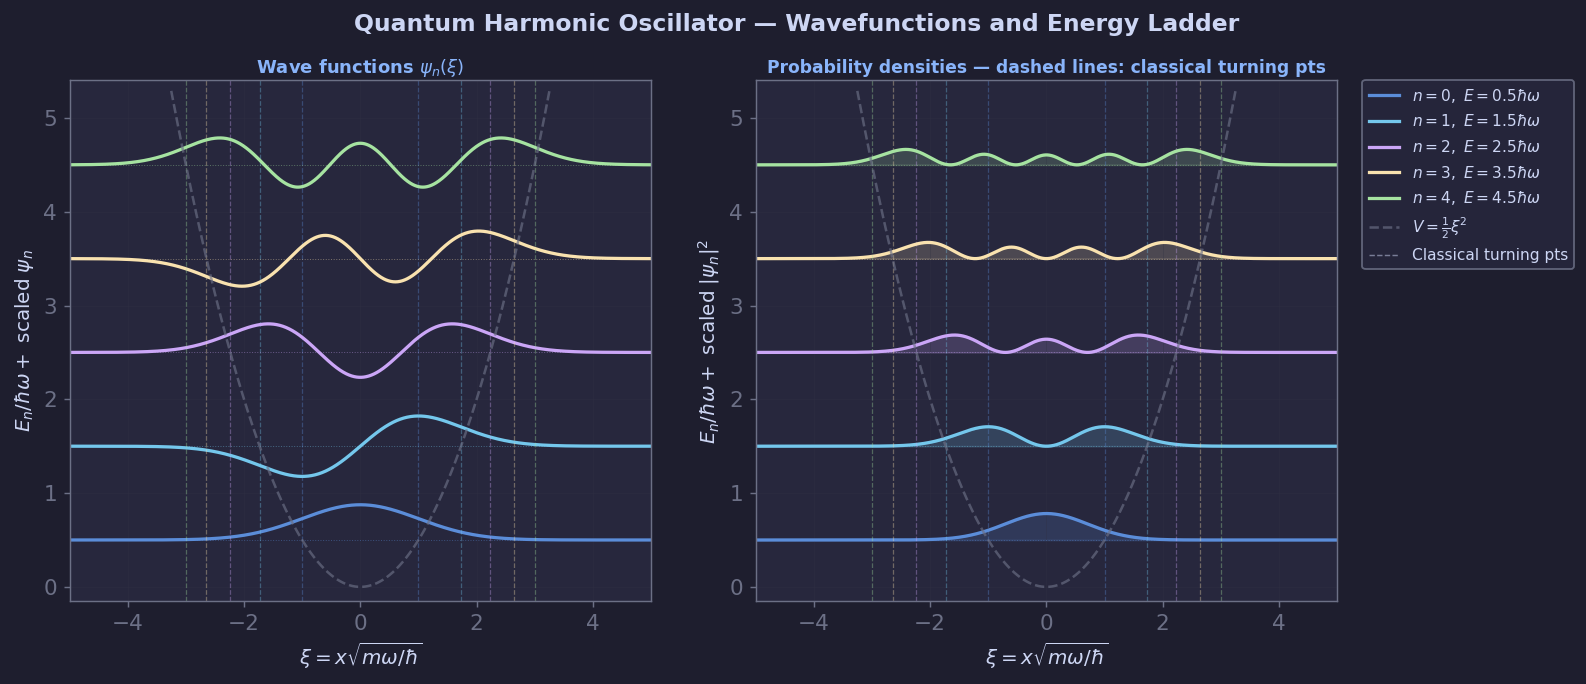

Fig 2 saved.


In [3]:
import math
xi = np.linspace(-5, 5, 1500)
ns = [0, 1, 2, 3, 4]
colors = [BLUE, TEAL, MAUVE, AMBER, GREEN]

def ho_psi(n, xi):
    Hn   = hermite(n)(xi)
    norm = (np.pi**0.5 * 2**n * math.factorial(n))**0.5
    return Hn * np.exp(-xi**2/2) / norm

# Figure: 1 row, 3 panels (ψ | |ψ|² | legend+info)
fig = plt.figure(figsize=(13, 5.2))
fig.suptitle('Quantum Harmonic Oscillator — Wavefunctions and Energy Ladder',
             color=FG, fontsize=13, fontweight='bold', y=0.98)
gs = fig.add_gridspec(1, 2, left=0.07, right=0.82, wspace=0.18)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

scale = 0.50
V = 0.5*xi**2

legend_handles = []
for n, col in zip(ns, colors):
    En  = n + 0.5
    psi = ho_psi(n, xi)
    xi_tp = np.sqrt(2*En)   # classical turning point

    l0, = ax0.plot(xi, scale*psi + En, color=col, lw=1.8,
                   label=fr'$n={n},\ E={En:.1f}\hbar\omega$')
    ax0.axhline(En, color=col, lw=0.55, ls=':', alpha=0.4)
    ax0.axvline( xi_tp, color=col, lw=0.7, ls='--', alpha=0.35)
    ax0.axvline(-xi_tp, color=col, lw=0.7, ls='--', alpha=0.35)

    ax1.fill_between(xi, En, scale*psi**2+En, alpha=0.18, color=col)
    ax1.plot(xi, scale*psi**2+En, color=col, lw=1.8)
    ax1.axhline(En, color=col, lw=0.55, ls=':', alpha=0.4)
    ax1.axvline( xi_tp, color=col, lw=0.7, ls='--', alpha=0.35)
    ax1.axvline(-xi_tp, color=col, lw=0.7, ls='--', alpha=0.35)
    legend_handles.append(l0)

# Potential on both panels
Vm = V < 5.3
for ax in [ax0, ax1]:
    ax.plot(xi[Vm], V[Vm], color=MUTED, lw=1.4, ls='--', alpha=0.65)
    ax.set_xlabel(r'$\xi=x\sqrt{m\omega/\hbar}$')
    ax.set_xlim(-5, 5); ax.set_ylim(-0.15, 5.4)
    ax.grid(True, alpha=0.35)

ax0.set_ylabel(r'$E_n/\hbar\omega +$ scaled $\psi_n$')
ax0.set_title(r'Wave functions $\psi_n(\xi)$', color=SKY, fontsize=10, pad=4)
ax1.set_ylabel(r'$E_n/\hbar\omega +$ scaled $|\psi_n|^2$')
ax1.set_title(r'Probability densities — dashed lines: classical turning pts',
              color=SKY, fontsize=9.5, pad=4)

# Single shared legend outside, right of ax1
legend_handles.append(
    plt.Line2D([0],[0], color=MUTED, lw=1.4, ls='--', alpha=0.65,
               label=r'$V=\frac{1}{2}\xi^2$'))
legend_handles.append(
    plt.Line2D([0],[0], color=FG, lw=0.8, ls='--', alpha=0.5,
               label='Classical turning pts'))

fig.legend(handles=legend_handles, fontsize=8.5,
           loc='upper left', bbox_to_anchor=(0.835, 0.88),
           framealpha=0.85, borderaxespad=0)

plt.savefig('ch02_fig2_harmonic_oscillator.png', **SAVEKW)
plt.show(); print('Fig 2 saved.')


## Fig 3 — Free Particle: Wave Packet Dispersion (§2.4)

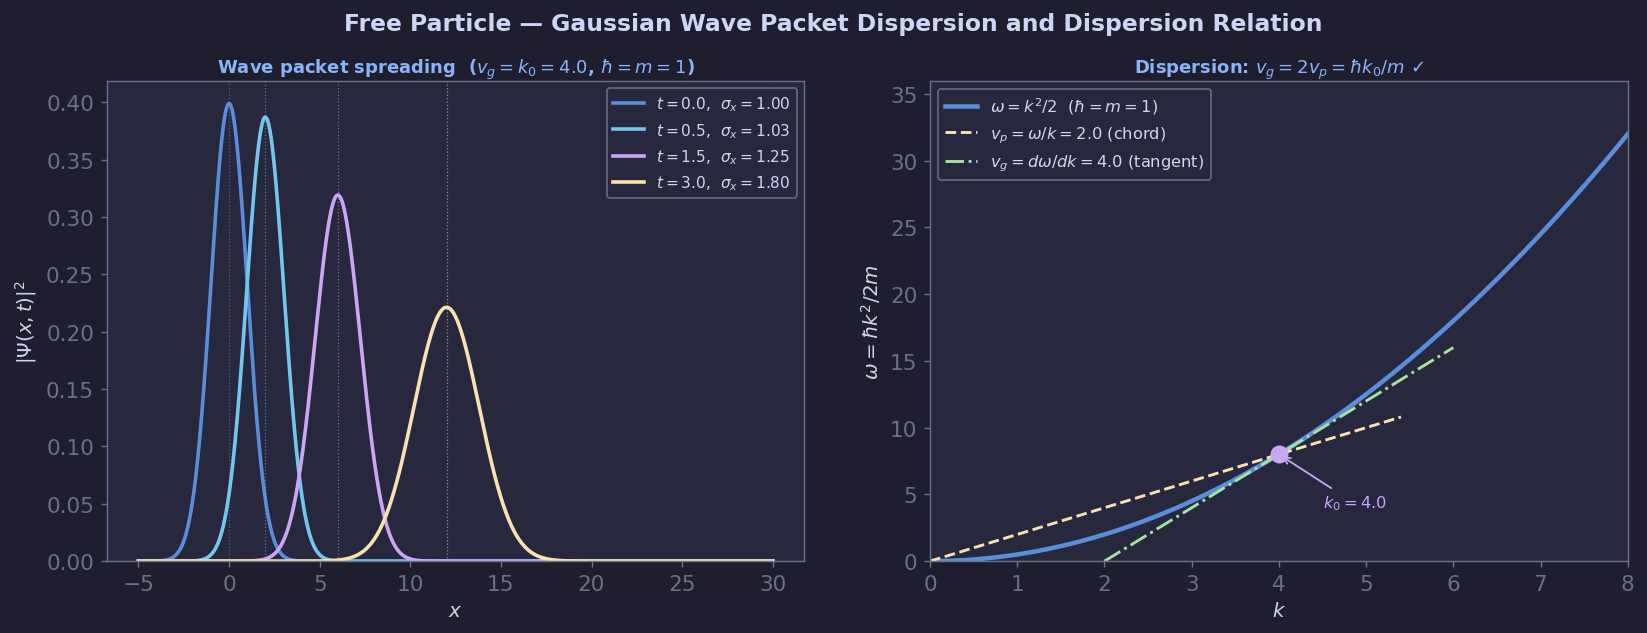

Fig 3 saved.  v_group=4.0,  v_phase=2.0  (v_g=2·v_p ✓)


In [4]:
k0   = 4.0
sig_k = 0.5              # σ_k
sig_x0 = 1/(2*sig_k)    # σ_x(t=0)

x = np.linspace(-5, 30, 2000)
times   = [0.0, 0.5, 1.5, 3.0]
cols_t  = [BLUE, TEAL, MAUVE, AMBER]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.18))
fig.suptitle('Free Particle — Gaussian Wave Packet Dispersion and Dispersion Relation',
             color=FG, fontsize=13, fontweight='bold', y=0.99)

# ── Left: spreading packet ────────────────────────────────────
ax = axes[0]
for t, col in zip(times, cols_t):
    sig_t   = sig_x0 * np.sqrt(1 + (t/(2*sig_x0**2))**2)
    xc      = k0 * t
    prob    = np.exp(-(x-xc)**2/(2*sig_t**2)) / (np.sqrt(2*np.pi)*sig_t)
    ax.plot(x, prob, color=col, lw=2,
            label=fr'$t={t}$,  $\sigma_x={sig_t:.2f}$')
    ax.axvline(xc, color=col, lw=0.7, ls=':', alpha=0.55)

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\Psi(x,t)|^2$')
ax.set_title(fr'Wave packet spreading  ($v_g = k_0 = {k0}$, $\hbar=m=1$)',
             color=SKY, fontsize=10, pad=4)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.35)
ax.legend(fontsize=8.5, loc='upper right', framealpha=0.85)

# ── Right: dispersion relation ─────────────────────────────────
ax2 = axes[1]
k  = np.linspace(0, 8, 600)
om = k**2/2
om0 = k0**2/2

ax2.plot(k, om, color=BLUE, lw=2.5, label=r'$\omega=k^2/2$  ($\hbar=m=1$)')

# Phase velocity chord
k_chord = np.array([0, k0*1.35])
ax2.plot(k_chord, k_chord*(om0/k0), color=AMBER, lw=1.6, ls='--',
         label=fr'$v_p=\omega/k={om0/k0:.1f}$ (chord)')

# Group velocity tangent
k_t = np.linspace(k0-2, k0+2, 100)
ax2.plot(k_t, om0+k0*(k_t-k0), color=GREEN, lw=1.6, ls='-.',
         label=fr'$v_g=d\omega/dk={k0:.1f}$ (tangent)')

ax2.scatter([k0], [om0], color=MAUVE, s=80, zorder=5)
ax2.annotate(fr'$k_0={k0}$', xy=(k0, om0), xytext=(k0+0.5, om0-4),
             color=MAUVE, fontsize=9,
             arrowprops=dict(arrowstyle='->', color=MAUVE, lw=1))

ax2.set_xlabel(r'$k$')
ax2.set_ylabel(r'$\omega=\hbar k^2/2m$')
ax2.set_title(r'Dispersion: $v_g=2v_p=\hbar k_0/m$ ✓',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=9, loc='upper left', framealpha=0.85)
ax2.grid(True, alpha=0.35)
ax2.set_xlim(0, 8); ax2.set_ylim(0, 36)

plt.savefig('ch02_fig3_free_particle.png', **SAVEKW)
plt.show()
print(f'Fig 3 saved.  v_group={k0:.1f},  v_phase={om0/k0:.1f}  (v_g=2·v_p ✓)')


## Fig 4 — Delta-Function Potential (§2.5)

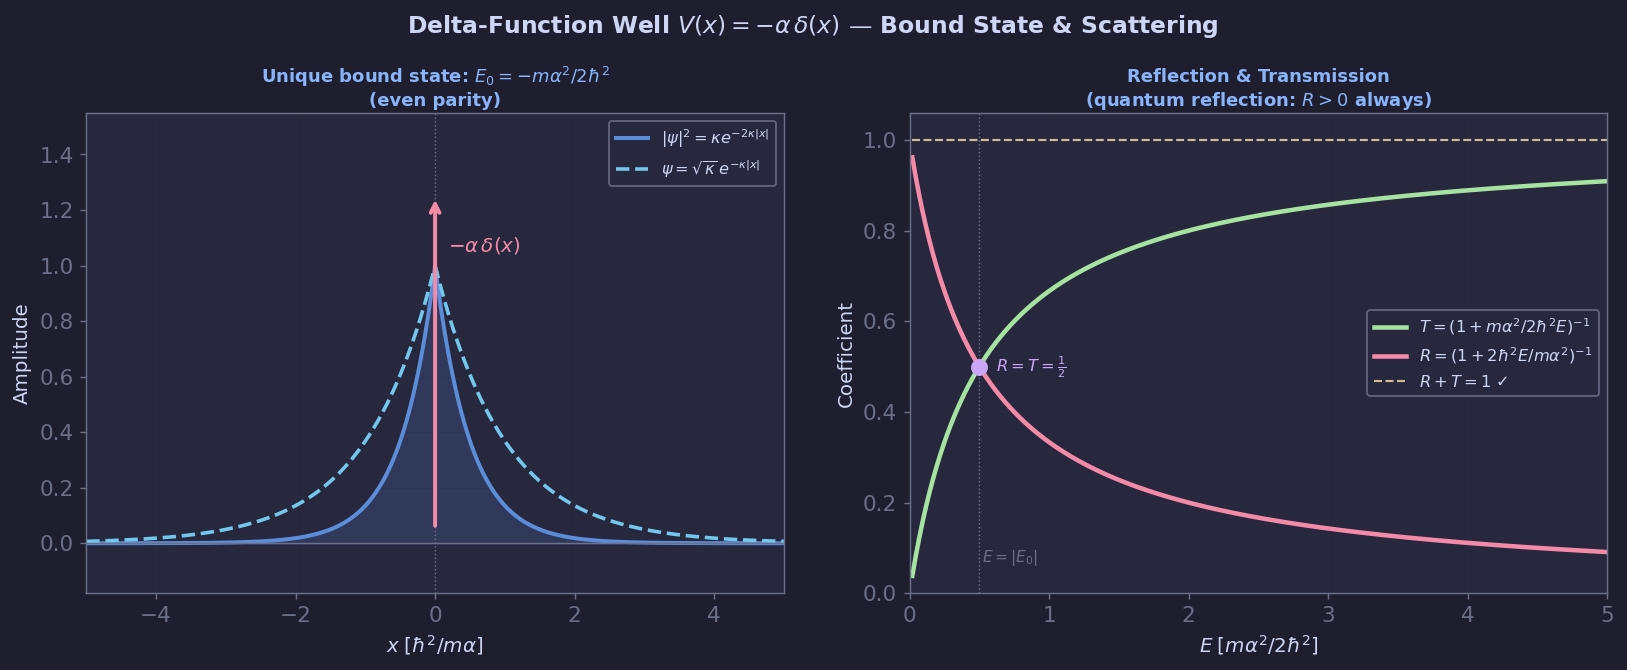

Fig 4 saved.  R+T at E=1: 1.00000000 ✓


In [5]:
kappa   = 1.0
E_bound = -kappa**2/2   # = -0.5

x = np.linspace(-5, 5, 1000)
psi  = np.sqrt(kappa)*np.exp(-kappa*np.abs(x))
prob = psi**2

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),
                         gridspec_kw=dict(left=0.07, right=0.97, wspace=0.18))
fig.suptitle(r'Delta-Function Well $V(x)=-\alpha\,\delta(x)$ — Bound State & Scattering',
             color=FG, fontsize=13, fontweight='bold', y=1.04)
fig.subplots_adjust(top=0.88, left=0.07, right=0.97, wspace=0.18)

# ── Left: bound state ─────────────────────────────────────────
ax = axes[0]
ax.fill_between(x, prob, alpha=0.18, color=BLUE)
ax.plot(x, prob,  color=BLUE, lw=2.2,
        label=r'$|\psi|^2=\kappa e^{-2\kappa|x|}$')
ax.plot(x, psi,   color=TEAL, lw=2.0, ls='--',
        label=r'$\psi=\sqrt{\kappa}\,e^{-\kappa|x|}$')
ax.annotate('', xy=(0,1.25), xytext=(0,0.05),
            arrowprops=dict(arrowstyle='->', color=RED, lw=2.2))
ax.text(0.18, 1.05, r'$-\alpha\,\delta(x)$', color=RED, fontsize=11)
ax.axvline(0, color=MUTED, lw=0.8, ls=':')
ax.axhline(0, color=MUTED, lw=0.8)
ax.set_xlabel(r'$x\;[\hbar^2/m\alpha]$')
ax.set_ylabel('Amplitude')
ax.set_title(r'Unique bound state: $E_0=-m\alpha^2/2\hbar^2$' + '\n(even parity)',
             color=SKY, fontsize=10, pad=4)
ax.legend(fontsize=9, loc='upper right', framealpha=0.85)
ax.grid(True, alpha=0.35)
ax.set_xlim(-5,5); ax.set_ylim(-0.18, 1.55)

# ── Right: R and T ────────────────────────────────────────────
ax2 = axes[1]
E   = np.linspace(0.02, 5, 600)
T   = 1/(1 + 1/(2*E))
R   = 1/(1 + 2*E)
ax2.plot(E, T,   color=GREEN, lw=2.5,
         label=r'$T=(1+m\alpha^2/2\hbar^2 E)^{-1}$')
ax2.plot(E, R,   color=RED,   lw=2.5,
         label=r'$R=(1+2\hbar^2 E/m\alpha^2)^{-1}$')
ax2.plot(E, R+T, color=AMBER, lw=1.2, ls='--', alpha=0.8, label=r'$R+T=1$ ✓')

ax2.axvline(0.5, color=MUTED, lw=0.8, ls=':')
ax2.text(0.52, 0.07, r'$E=|E_0|$', color=MUTED, fontsize=8.5)
# R=T=½ crossing
ax2.scatter([0.5],[0.5], color=MAUVE, s=70, zorder=5)
ax2.text(0.62, 0.49, r'$R=T=\frac{1}{2}$', color=MAUVE, fontsize=9)

ax2.set_xlabel(r'$E\;[m\alpha^2/2\hbar^2]$')
ax2.set_ylabel('Coefficient')
ax2.set_title('Reflection & Transmission\n' + r'(quantum reflection: $R>0$ always)',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=9, loc='center right', framealpha=0.85)
ax2.grid(True, alpha=0.35)
ax2.set_xlim(0,5); ax2.set_ylim(0,1.06)

plt.savefig('ch02_fig4_delta_potential.png', **SAVEKW)
plt.show()
idx = np.argmin(np.abs(E-1))
print(f'Fig 4 saved.  R+T at E=1: {R[idx]+T[idx]:.8f} ✓')


## Fig 5 — Finite Square Well (§2.6)

z0=6.0, V0=18  →  4 bound states (correct: 4):
  n=1 (e): z=1.3448, E=-17.096, κ=5.8474
  n=2 (o): z=2.6788, E=-14.412, κ=5.3688
  n=3 (e): z=3.9858, E=-10.057, κ=4.4848
  n=4 (o): z=5.2260, E=-4.345, κ=2.9478


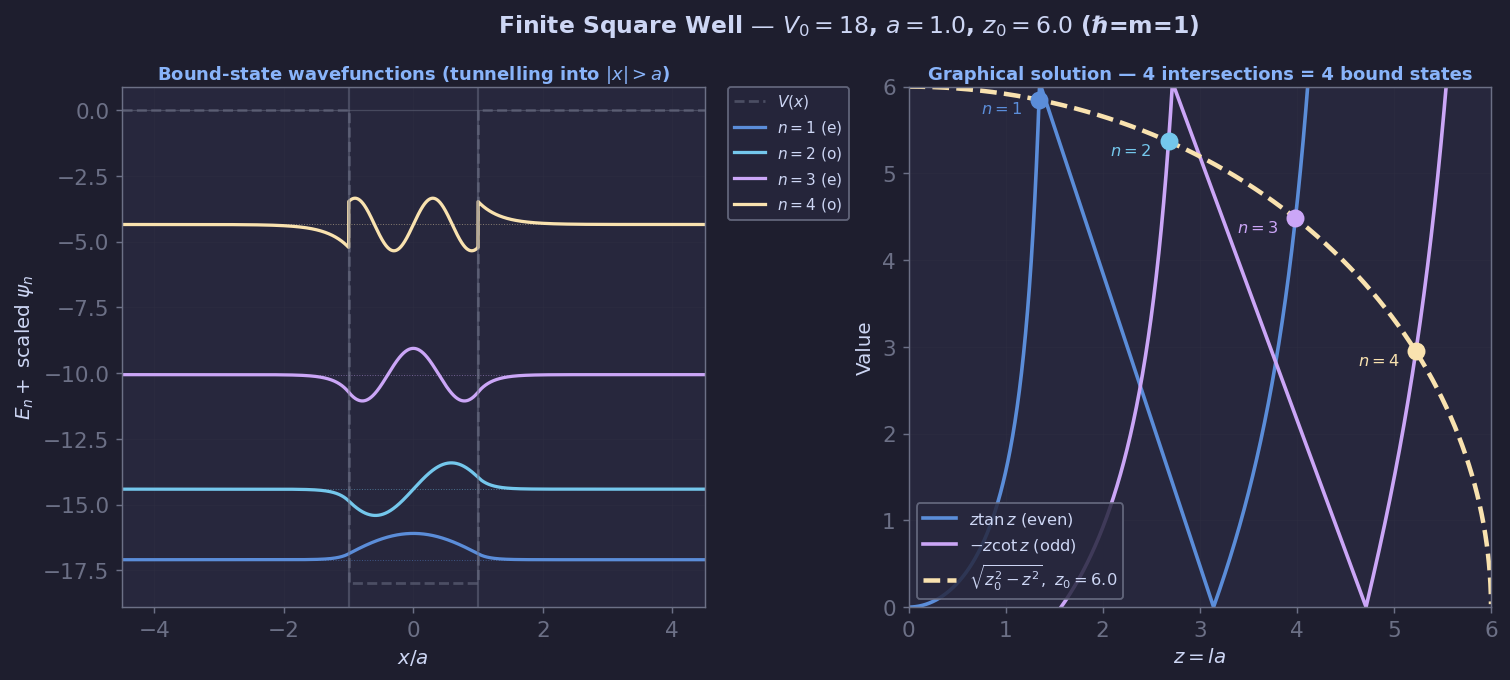

Fig 5 saved.  4 bound states ✓


In [6]:
# Finite square well — CORRECTED bound-state finder
# Bug fix: filter out tan/cot pole crossings by requiring
#          |lhs| < 2*z0  before accepting a sign change.
a  = 1.0; z0 = 6.0; V0 = z0**2/2   # V0=18, natural units ℏ=m=1

def find_bound_states(z0, a=1.0):
    V0  = z0**2/2
    z   = np.linspace(1e-6, z0-1e-6, 80000)
    rhs = np.sqrt(np.maximum(z0**2-z**2, 0))
    states = []
    for parity in ['even','odd']:
        raw  = z*np.tan(z) if parity=='even' else -z/np.tan(z)
        diff = raw - rhs
        for i in range(len(z)-1):
            if (np.isfinite(diff[i]) and np.isfinite(diff[i+1]) and
                    abs(raw[i]) < 2*z0 and abs(raw[i+1]) < 2*z0 and
                    diff[i]*diff[i+1] < 0):
                try:
                    if parity=='even':
                        f = lambda zz: zz*np.tan(zz)-np.sqrt(max(z0**2-zz**2,1e-15))
                    else:
                        f = lambda zz: -zz/np.tan(zz)-np.sqrt(max(z0**2-zz**2,1e-15))
                    zs = brentq(f, z[i]+1e-10, z[i+1]-1e-10, xtol=1e-12)
                    ks = np.sqrt(max(z0**2-zs**2,0))/a
                    Es = zs**2/(2*a**2)-V0
                    if -V0 < Es < 0:
                        states.append((zs, ks, Es, parity))
                except Exception:
                    pass
    states.sort(key=lambda s: s[2])
    return states, V0

states, V0 = find_bound_states(z0)
print(f'z0={z0}, V0={V0:.0f}  →  {len(states)} bound states (correct: 4):')
for i,(zs,ks,Es,par) in enumerate(states):
    print(f'  n={i+1} ({par[0]}): z={zs:.4f}, E={Es:.3f}, κ={ks:.4f}')

cols  = [BLUE, TEAL, MAUVE, AMBER]
x_p   = np.linspace(-4.5*a, 4.5*a, 4000)

fig = plt.figure(figsize=(13, 5.2))
fig.suptitle(fr'Finite Square Well — $V_0={V0:.0f}$, $a={a}$, $z_0={z0}$ (ℏ=m=1)',
             color=FG, fontsize=13, fontweight='bold', y=0.99)
gs = fig.add_gridspec(1, 2, left=0.07, right=0.88, wspace=0.35)
ax  = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ── Left: wavefunctions ───────────────────────────────────────
ax.plot([-4.5,-1,-1,1,1,4.5], [0,0,-V0,-V0,0,0],
        color=MUTED, lw=1.5, ls='--', alpha=0.55, label='$V(x)$')
ax.axhline(0, color=MUTED, lw=0.7, alpha=0.45)

scale = 1.0
for i,(zs,ks,Es,par) in enumerate(states):
    col = cols[i]
    psi = np.where(
        np.abs(x_p) <= a,
        np.cos(zs*x_p/a) if par=='even' else np.sin(zs*x_p/a),
        (np.cos(zs) if par=='even' else np.abs(np.sin(zs))) *
        np.sign(x_p if par=='odd' else np.ones_like(x_p)) *
        np.exp(-ks*(np.abs(x_p)-a))
    )
    psi = psi / max(np.max(np.abs(psi)), 1e-12)
    ax.plot(x_p, scale*psi+Es, color=col, lw=1.8,
            label=rf'$n={i+1}$ ({par[0]})') # + '\n' + rf'$E={Es:.1f}$')
    ax.axhline(Es, color=col, lw=0.55, ls=':', alpha=0.45)

ax.axvline(-a, color=MUTED, lw=1.2, alpha=0.5)
ax.axvline( a, color=MUTED, lw=1.2, alpha=0.5)
ax.set_xlabel(r'$x/a$')
ax.set_ylabel(r'$E_n +$ scaled $\psi_n$')
ax.set_title(r'Bound-state wavefunctions (tunnelling into $|x|>a$)',
             color=SKY, fontsize=10, pad=4)
ax.grid(True, alpha=0.35)
ax.set_xlim(-4.5, 4.5)
# Legend outside right
ax.legend(fontsize=8.5, loc='upper left',
          bbox_to_anchor=(1.04, 1.0), borderaxespad=0, framealpha=0.85)

# ── Right: graphical solution ─────────────────────────────────
z   = np.linspace(1e-4, z0-1e-4, 8000)
rhs = np.sqrt(np.maximum(z0**2-z**2, 0))

for parity, col_l, lbl in [('even', BLUE,  r'$z\tan z$ (even)'),
                             ('odd',  MAUVE, r'$-z\cot z$ (odd)')]:
    raw = z*np.tan(z) if parity=='even' else -z/np.tan(z)
    # Keep only physically relevant segments (≥0 and < z0)
    good = np.isfinite(raw) & (raw >= -0.05) & (raw < z0+0.1)
    # Split at discontinuities (poles) where |Δraw| > z0
    jumps = np.where(np.abs(np.diff(np.where(good, raw, np.nan))) > z0)[0]
    segs  = np.split(np.where(good)[0], np.searchsorted(np.where(good)[0], jumps+1))
    first = True
    for seg in segs:
        if len(seg) < 4: continue
        rm = raw[seg]; zm = z[seg]
        # Clip to visible range
        clip = (rm >= 0) & (rm <= z0+0.05)
        if clip.sum() < 2: continue
        ax2.plot(zm[clip], rm[clip], color=col_l, lw=2,
                 label=lbl if first else None)
        first = False

ax2.plot(z, rhs, color=AMBER, lw=2.5, ls='--',
         label=fr'$\sqrt{{z_0^2-z^2}},\ z_0={z0}$')

for i,(zs,ks,Es,par) in enumerate(states):
    rv  = np.sqrt(max(z0**2-zs**2, 0))
    col = cols[i]
    ax2.scatter([zs],[rv], s=80, color=col, zorder=5)
    ax2.text(zs-0.6, rv-0.16, fr'$n={i+1}$', color=col, fontsize=9)

ax2.set_xlabel(r'$z=la$')
ax2.set_ylabel('Value')
ax2.set_title(fr'Graphical solution — {len(states)} intersections = {len(states)} bound states',
              color=SKY, fontsize=10, pad=4)
ax2.legend(fontsize=9, loc='lower left', framealpha=0.85)
ax2.grid(True, alpha=0.35)
ax2.set_xlim(0, z0); ax2.set_ylim(0, z0)

plt.savefig('ch02_fig5_finite_well.png', **SAVEKW)
plt.show()
print(f'Fig 5 saved.  {len(states)} bound states ✓')


## Download all figures

In [7]:
import zipfile, os, glob
from google.colab import files

zip_name = 'ch02_figures.zip'
fig_files = sorted(glob.glob('ch02_fig*.png'))

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fn in fig_files:
        zf.write(fn)
        print(f'  added: {fn}')

print(f'\nZip created: {zip_name}  ({os.path.getsize(zip_name)/1024:.0f} KB)')
files.download(zip_name)

  added: ch02_fig1_infinite_well.png
  added: ch02_fig2_harmonic_oscillator.png
  added: ch02_fig3_free_particle.png
  added: ch02_fig4_delta_potential.png
  added: ch02_fig5_finite_well.png

Zip created: ch02_figures.zip  (746 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>